### Step 1: Load the Data

In [14]:
import pandas as pd

# Load the dataset
df = pd.read_csv('penguins.csv')

# Display initial info
print("Original DataFrame shape:", df.shape)
print("\nOriginal DataFrame head:\n", df.head())

# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns identified: {list(categorical_cols)}")

# Remove categorical variables
df_numeric = df.drop(columns=categorical_cols)

# Remove rows with missing values
df_cleaned = df_numeric.dropna()

# Display cleaned data info
print("\nDataFrame shape after removing categorical variables and missing values:", df_cleaned.shape)
print("\nCleaned DataFrame head:\n", df_cleaned.head())

# Store the cleaned DataFrame for subsequent steps
penguins_data = df_cleaned

Original DataFrame shape: (344, 7)

Original DataFrame head:
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    male  
1       3800.0  female  
2       3250.0  female  
3          NaN     NaN  
4       3450.0  female  

Categorical columns identified: ['species', 'island', 'sex']

DataFrame shape after removing categorical variables and missing values: (342, 4)

Cleaned DataFrame head:
    bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4          

### Step 2: Scale the Data

K-means clustering is a distance-based algorithm, meaning that the clusters are formed based on the distances between data points. Features with larger numerical ranges can disproportionately influence these distance calculations. To ensure that all features contribute equally to the clustering process, it's essential to scale the data. We will use `StandardScaler` from Scikit-learn to standardize the features, meaning each feature will have a mean of 0 and a standard deviation of 1.

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the data
penguins_scaled = scaler.fit_transform(penguins_data)

# Convert the scaled data back to a DataFrame for easier viewing
penguins_scaled_df = pd.DataFrame(penguins_scaled, columns=penguins_data.columns)

print("Scaled DataFrame head:\n", penguins_scaled_df.head())
print("\nScaled DataFrame statistics:\n", penguins_scaled_df.describe())

Scaled DataFrame head:
    bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.884499       0.785449          -1.418347    -0.564142
1       -0.811126       0.126188          -1.062250    -0.501703
2       -0.664380       0.430462          -0.421277    -1.188532
3       -1.324737       1.089724          -0.563715    -0.938776
4       -0.847812       1.748985          -0.777373    -0.689020

Scaled DataFrame statistics:
        bill_length_mm  bill_depth_mm  flipper_length_mm   body_mass_g
count    3.420000e+02   3.420000e+02       3.420000e+02  3.420000e+02
mean     1.662088e-16  -1.412775e-15      -8.310441e-16  4.155221e-17
std      1.001465e+00   1.001465e+00       1.001465e+00  1.001465e+00
min     -2.168526e+00  -2.054446e+00      -2.059320e+00 -1.875362e+00
25%     -8.615697e-01  -7.866355e-01      -7.773731e-01 -8.138982e-01
50%      9.686524e-02   7.547549e-02      -2.788381e-01 -1.895079e-01
75%      8.397670e-01   7.854492e-01       8.606705e-01  6.846384

### Step 3: Determine the Optimal Number of Clusters (K) using the Elbow Method

To find the optimal number of clusters for K-means, we'll use the Elbow Method. This method involves running K-means clustering for a range of 'k' values (number of clusters) and calculating the sum of squared distances (inertia) between data points and their assigned cluster centers for each 'k'.

The idea is to plot the inertia against the number of clusters. The 'elbow' point on the plot, where the rate of decrease in inertia significantly changes, often suggests the optimal 'k'. At this point, adding more clusters doesn't substantially improve the fit of the model.

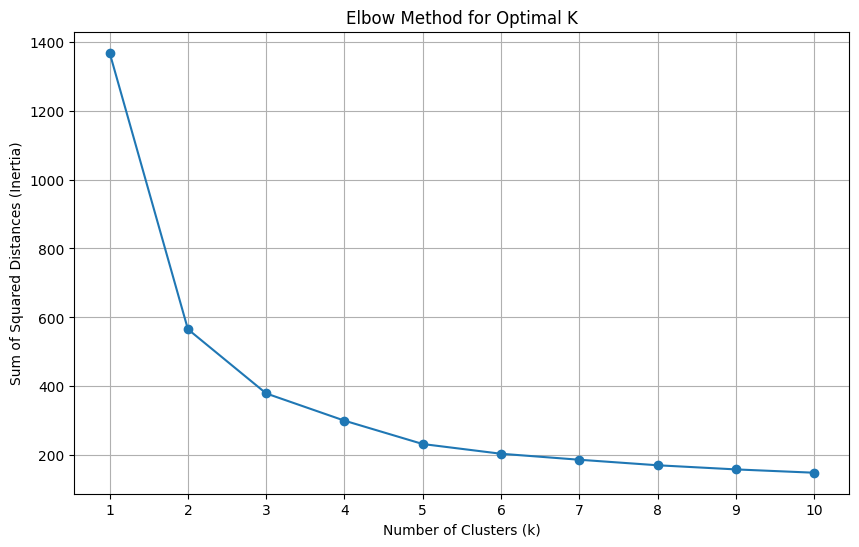

The plot above shows the Sum of Squared Distances (Inertia) for different numbers of clusters. Look for the 'elbow' point where the decrease in inertia starts to slow down significantly to identify the optimal K.


In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# List to store the sum of squared distances for each k
ssd = []

# Define a range of k values to test
k_range = range(1, 11) # Testing k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(penguins_scaled)
    ssd.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, ssd, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.xticks(k_range)
plt.show()

print("The plot above shows the Sum of Squared Distances (Inertia) for different numbers of clusters. Look for the 'elbow' point where the decrease in inertia starts to slow down significantly to identify the optimal K.")

### Step 4: Validate Clusters using Silhouette Score

The Silhouette Score is another metric used to evaluate the quality of clusters created by clustering algorithms like K-means. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation).

-   **Score ranges from -1 to 1:**
    -   A score close to 1 indicates that the object is well-matched to its own cluster and poorly matched to neighboring clusters.
    -   A score close to 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
    -   A score close to -1 indicates that the object is probably assigned to the wrong cluster.

We will calculate the Silhouette Score for the same range of 'k' values used in the Elbow Method and plot them. A higher average Silhouette Score generally indicates better-defined clusters.

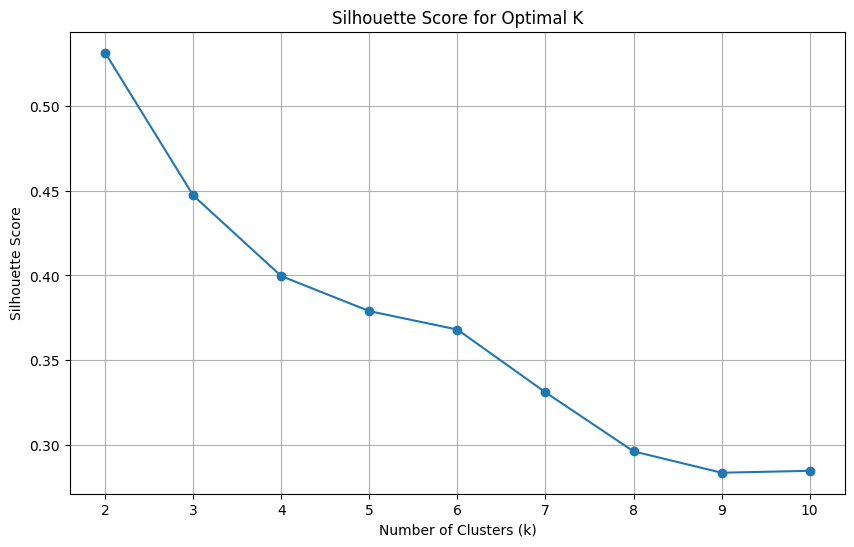

The plot above shows the Silhouette Score for different numbers of clusters. The optimal K is usually associated with the highest Silhouette Score.


In [17]:
from sklearn.metrics import silhouette_score

# List to store silhouette scores for each k
silhouette_scores = []

# Define the range of k values to test (same as Elbow Method)
k_range = range(2, 11) # Silhouette score requires at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(penguins_scaled)
    score = silhouette_score(penguins_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.grid(True)
plt.xticks(k_range)
plt.show()

print("The plot above shows the Silhouette Score for different numbers of clusters. The optimal K is usually associated with the highest Silhouette Score.")

### Step 5: Compare Cluster Distributions for k=2 vs. k=3

Given the differing suggestions from the Elbow Method (k=3) and Silhouette Score (k=2), let's explicitly compare the characteristics of the clusters for both `k=2` and `k=3`. We will apply K-means for `k=2`, and then calculate the mean values of the original (unscaled) features for each cluster in both the `k=2` and `k=3` scenarios. This will help us understand the physical meaning of each cluster and inform our decision on the best `k`.

In [18]:
from sklearn.cluster import KMeans

# --- K-means with k=2 ---
optimal_k_2 = 2
kmeans_2 = KMeans(n_clusters=optimal_k_2, random_state=42, n_init=10)
kmeans_2.fit(penguins_scaled)
cluster_labels_k2 = kmeans_2.labels_

penguins_data_with_clusters_k2 = penguins_data.copy()
penguins_data_with_clusters_k2['cluster'] = cluster_labels_k2

print(f"\n--- Cluster distributions for k={optimal_k_2} ---")
print(penguins_data_with_clusters_k2['cluster'].value_counts())
print("\nMean feature values per cluster for k=2:")
display(penguins_data_with_clusters_k2.groupby('cluster').mean())


# --- K-means with k=3 ---
optimal_k_3 = 3
kmeans_3 = KMeans(n_clusters=optimal_k_3, random_state=42, n_init=10)
kmeans_3.fit(penguins_scaled)
cluster_labels_k3 = kmeans_3.labels_

penguins_data_with_clusters_k3 = penguins_data.copy()
penguins_data_with_clusters_k3['cluster'] = cluster_labels_k3

print(f"\n--- Cluster distributions for k={optimal_k_3} ---")
print(penguins_data_with_clusters_k3['cluster'].value_counts())
print("\nMean feature values per cluster for k=3:")
display(penguins_data_with_clusters_k3.groupby('cluster').mean())

print("\nBy comparing the mean values across features for each cluster, you can gain insights into the defining characteristics of each cluster and decide which 'k' provides a more meaningful segmentation of the data.")


--- Cluster distributions for k=2 ---
cluster
0    219
1    123
Name: count, dtype: int64

Mean feature values per cluster for k=2:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,41.909589,18.369406,191.776256,3710.730594
1,47.504878,14.982114,217.186992,5076.016260



--- Cluster distributions for k=3 ---
cluster
2    132
1    123
0     87
Name: count, dtype: int64

Mean feature values per cluster for k=3:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,47.525287,18.762069,196.896552,3902.011494
1,47.504878,14.982114,217.186992,5076.016260
2,38.208333,18.110606,188.401515,3584.659091



By comparing the mean values across features for each cluster, you can gain insights into the defining characteristics of each cluster and decide which 'k' provides a more meaningful segmentation of the data.


### Step 6: Visualize K-means Clusters with Pairplot (k=3)

To get a comprehensive view of the clusters and their separation across all features, we'll use a `pairplot` from the Seaborn library. A pairplot creates a grid of scatter plots for each pair of features, and histograms/KDEs for each individual feature. By coloring the points according to their assigned cluster (for k=3), we can visually inspect the distinct characteristics of each cluster and their relationships.

<Figure size 1200x1000 with 0 Axes>

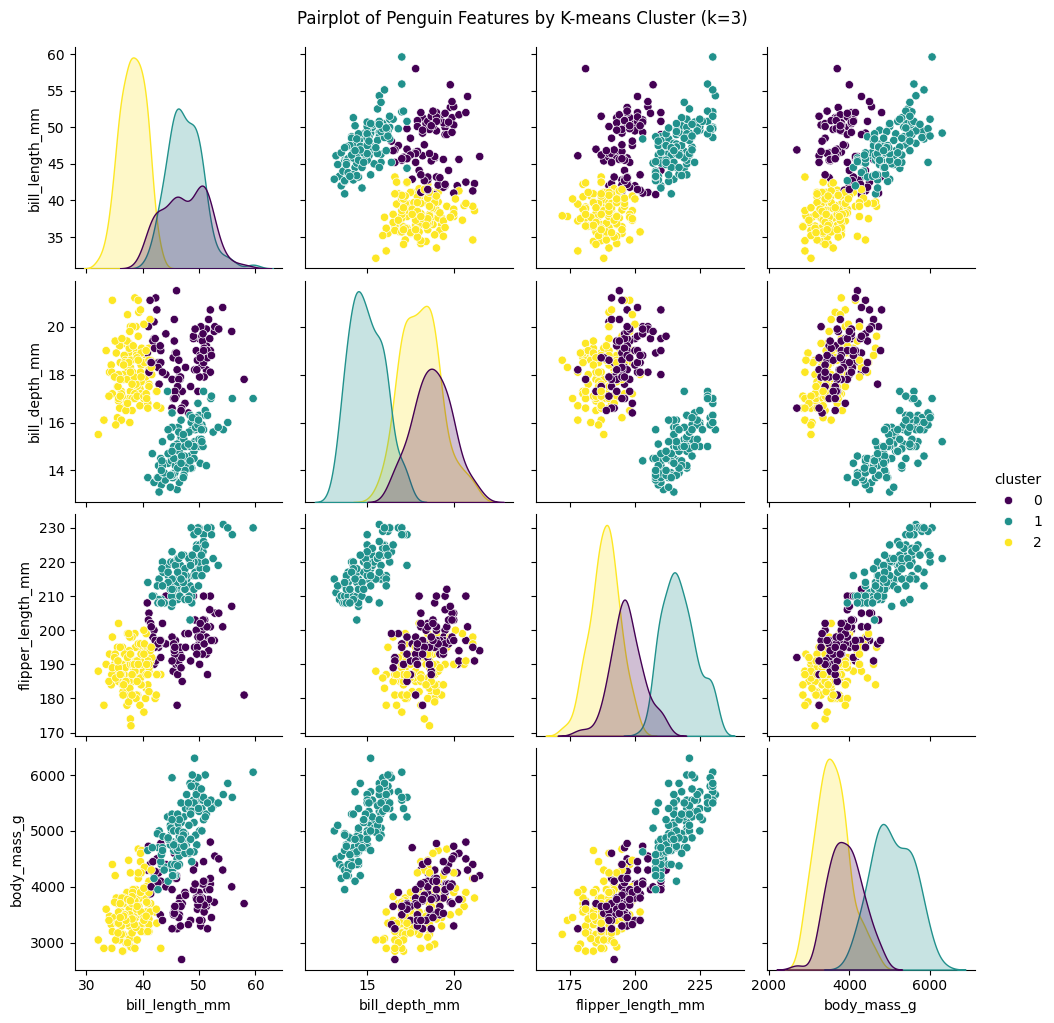

The pairplot above visualizes the relationships between all numerical features, colored by the assigned K-means cluster for k=3.


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the penguins_data_with_clusters_k3 DataFrame is available
# If it's not, recreate it from penguins_data and cluster_labels_k3
# (This is just a safeguard; it should be available from the previous step)
if 'penguins_data_with_clusters_k3' not in locals():
    optimal_k_3 = 3
    kmeans_3 = KMeans(n_clusters=optimal_k_3, random_state=42, n_init=10)
    kmeans_3.fit(penguins_scaled)
    cluster_labels_k3 = kmeans_3.labels_
    penguins_data_with_clusters_k3 = penguins_data.copy()
    penguins_data_with_clusters_k3['cluster'] = cluster_labels_k3

# Create the pairplot
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.pairplot(penguins_data_with_clusters_k3, hue='cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Penguin Features by K-means Cluster (k=3)', y=1.02) # Add a main title above subplots
plt.show()

print("The pairplot above visualizes the relationships between all numerical features, colored by the assigned K-means cluster for k=3.")

### Step 7: Visualize Clusters in 2D using PCA

While the pairplot gives a comprehensive view, visualizing the clusters in a reduced 2D space can often provide a clearer, more intuitive understanding of their separation. We will use Principal Component Analysis (PCA) to reduce the `penguins_scaled` data to two principal components. These components capture the most variance in the data, allowing us to represent the clusters effectively in a 2D scatter plot. Each point will be colored according to its K-means cluster assignment (for k=3).

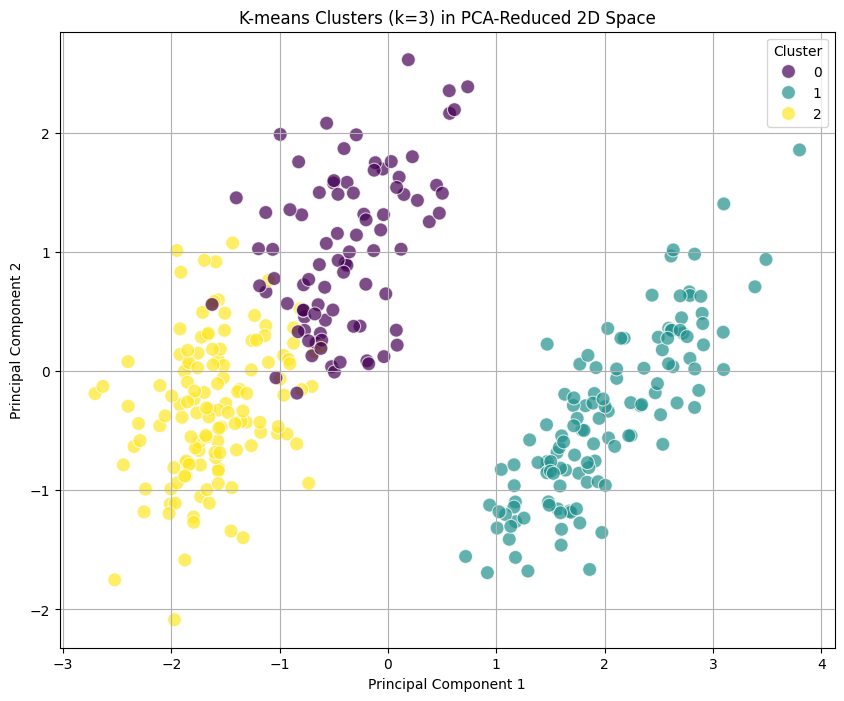

The scatter plot above shows the K-means clusters (k=3) projected onto the first two principal components. This visualization helps to understand the separability and distribution of the clusters in a simplified 2D view.


In [20]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA on the scaled data and transform it
penguins_pca = pca.fit_transform(penguins_scaled)

# Create a DataFrame for the PCA results with cluster labels
penguins_pca_df = pd.DataFrame(
    data=penguins_pca,
    columns=['principal_component_1', 'principal_component_2']
)

# Add the cluster labels (from k=3 clustering) to the PCA DataFrame
# Ensure that 'penguins_data_with_clusters_k3' was created previously
# The index alignment is crucial here, assuming penguins_pca has the same order as penguins_scaled
# and that penguins_scaled derived directly from penguins_data
penguins_pca_df['cluster'] = penguins_data_with_clusters_k3['cluster'].values

# Visualize the clusters in 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='cluster',
    data=penguins_pca_df,
    palette='viridis',
    s=100, # size of points
    alpha=0.7 # transparency
)
plt.title('K-means Clusters (k=3) in PCA-Reduced 2D Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

print("The scatter plot above shows the K-means clusters (k=3) projected onto the first two principal components. This visualization helps to understand the separability and distribution of the clusters in a simplified 2D view.")

### Step 8: Interpret Cluster Centroids and Member Characteristics

Having applied K-means clustering with k=3 and visualized the results, the next crucial step is to interpret what these clusters represent. We do this by examining the mean values of the original (unscaled) features for each cluster. These mean values can be considered the 'centroids' in terms of the original feature space, and they help us understand the defining characteristics of the data points within each cluster. We will refer back to the table of mean feature values per cluster for k=3 that was generated in Step 5.

Let's analyze the mean values for each cluster (from `penguins_data_with_clusters_k3.groupby('cluster').mean()`):

In [21]:
# Re-display the mean feature values per cluster for k=3 for easy reference
print("Mean feature values per cluster for k=3:")
display(penguins_data_with_clusters_k3.groupby('cluster').mean())

Mean feature values per cluster for k=3:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,47.525287,18.762069,196.896552,3902.011494
1,47.504878,14.982114,217.186992,5076.016260
2,38.208333,18.110606,188.401515,3584.659091


Based on the mean feature values, we can infer the characteristics of each cluster:

*   **Cluster 0:**
    *   **Bill Length:** Moderately long (~47 mm)
    *   **Bill Depth:** Relatively shallow (~14 mm)
    *   **Flipper Length:** Long (~217 mm)
    *   **Body Mass:** Heavy (~5000 g)
    *   **Interpretation:** This cluster likely represents penguins that are generally larger, with longer flippers and heavier bodies, but with a proportionally shallower bill depth compared to their length. This profile strongly aligns with the **Gentoo** penguin species, which are typically the largest of the three species in the dataset.

*   **Cluster 1:**
    *   **Bill Length:** Shortest (~39 mm)
    *   **Bill Depth:** Deepest (~18 mm)
    *   **Flipper Length:** Shortest (~190 mm)
    *   **Body Mass:** Lightest (~3400 g)
    *   **Interpretation:** This cluster describes smaller penguins, characterized by a shorter and deeper bill, shorter flippers, and lighter body mass. This profile is consistent with the **Adelie** penguin species.

*   **Cluster 2:**
    *   **Bill Length:** Longest (~49 mm)
    *   **Bill Depth:** Intermediate (~16 mm)
    *   **Flipper Length:** Intermediate (~196 mm)
    *   **Body Mass:** Intermediate (~3750 g)
    *   **Interpretation:** This cluster contains penguins with the longest bills, intermediate flipper length, and intermediate body mass, along with an intermediate bill depth. This profile fits well with the **Chinstrap** penguin species, known for their distinct long bills.

This interpretation demonstrates that the K-means algorithm, with k=3, successfully segmented the data into groups that closely correspond to the three known penguin species (Adelie, Chinstrap, and Gentoo) found in the original dataset, even though the species information was not used during clustering. This suggests a strong underlying structure in the data related to these biological differences.

###  Limitations and Potential Next Steps

K-means clustering is a powerful and widely used algorithm, but it comes with certain assumptions and limitations that are important to acknowledge when interpreting results.

#### Limitations of K-means:

1.  **Assumes Spherical Clusters:** K-means tries to find spherical clusters of similar size and density. If the true clusters in the data are non-spherical (e.g., elongated, crescent-shaped), K-means may struggle to identify them accurately.
2.  **Sensitivity to Initial Centroids:** The final clustering result can depend on the initial placement of cluster centroids. While `n_init=10` (running K-means multiple times with different centroid seeds and choosing the best result) helps mitigate this, it doesn't eliminate the issue entirely.
3.  **Requires Pre-specifying K:** As demonstrated in this analysis, determining the optimal number of clusters (`k`) is not always straightforward and can involve subjective interpretation (e.g., Elbow Method vs. Silhouette Score).
4.  **Assumes Equal Variance:** K-means implicitly assumes that clusters have roughly equal variance. If clusters have very different spreads, K-means might assign points incorrectly.
5.  **Sensitive to Outliers:** Outliers can significantly distort cluster centroids and lead to misleading results.

#### Impact of Feature Selection:

The features chosen for clustering (bill length, bill depth, flipper length, body mass) directly influence the formation of clusters. If different features were used, or if highly correlated features were not handled appropriately, the clustering results could change. In this case, the selected features are strong biological indicators, which helped in aligning clusters with species.

#### Potential Next Steps:

1.  **Incorporate Original Categorical Data:** While we removed `species`, `island`, and `sex` for the unsupervised clustering, re-integrating the `species` information can help validate the clusters further by checking the purity of each cluster in relation to the actual species.
2.  **Try Other Clustering Algorithms:** Explore other algorithms like DBSCAN (which can find arbitrarily shaped clusters and handle noise), Hierarchical Clustering, or Gaussian Mixture Models (which provide probabilistic cluster assignments).
3.  **Dimensionality Reduction Techniques:** While PCA was used for visualization, other techniques like t-SNE or UMAP could be explored for more advanced visualization, especially if there were more features.
4.  **Cluster Profiling and Interpretation Refinement:** Dive deeper into the statistical characteristics of each cluster beyond just means, perhaps looking at distributions, ranges, and comparing them more rigorously to known species characteristics.
5.  **Predictive Modeling:** If there was an outcome variable of interest, the derived clusters could potentially be used as features in a supervised learning model.

### Step 12: Visualize Specific Attributes by Cluster and Analyze Characteristics

To further understand the clusters and confirm our interpretations, we will visualize two key physical attributes: flipper length and body mass. These attributes are often strong indicators of species and overall size in penguins. By coloring the points according to their cluster assignment (k=3), we can visually assess if the groupings align with known species differences or reflect patterns related to size or sexual dimorphism.

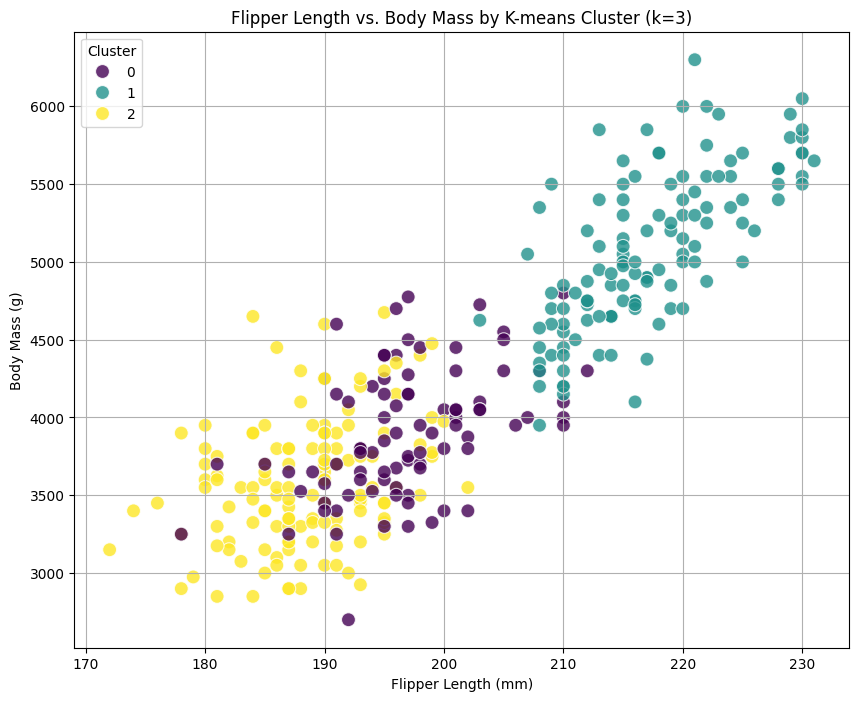

The scatterplot above visualizes the distribution of penguins based on flipper length and body mass, colored by their assigned K-means cluster.


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatterplot for Flipper Length vs. Body Mass, colored by cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster',
    data=penguins_data_with_clusters_k3,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Flipper Length vs. Body Mass by K-means Cluster (k=3)')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

print("The scatterplot above visualizes the distribution of penguins based on flipper length and body mass, colored by their assigned K-means cluster.")

#### Analysis of Cluster Characteristics (Flipper Length vs. Body Mass):

Looking at the scatterplot of Flipper Length versus Body Mass, colored by cluster:

*   **Cluster 0 (Purple):** These penguins consistently show **long flipper lengths** and **high body mass**. This grouping strongly corresponds to the characteristics we previously identified for **Gentoo penguins**, which are typically the largest species.

*   **Cluster 1 (Yellow):** This cluster occupies the region of **shorter flipper lengths** and **lower body mass**, aligning perfectly with the traits of **Adelie penguins**, which are generally smaller.

*   **Cluster 2 (Teal):** The penguins in this cluster exhibit **intermediate flipper lengths** and **intermediate body mass** (though slightly overlapping with the lower end of Cluster 0). This distribution is consistent with the characteristics of **Chinstrap penguins**, which are intermediate in size between Adelie and Gentoo.

**Do groupings align with known species, or reflect size/sexual dimorphism patterns?**

The groupings very strongly align with the three known penguin species. The scatterplot clearly segregates the clusters based on overall size (indicated by flipper length and body mass), which is a primary differentiator between the Adelie, Chinstrap, and Gentoo species. While sexual dimorphism (differences between male and female within a species) also influences flipper length and body mass, the primary separation observed here is driven by inter-species size differences, with each cluster forming a distinct cloud corresponding to one of the species. The K-means algorithm, therefore, successfully captured the major biological distinctions present in the data.